In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, FunctionTransformer

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df=pd.read_csv("final_database.csv")

In [3]:
# Fill missing values in the DataFrame
def fill_missing_values(df):
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(0).astype(int)
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

df = fill_missing_values(df)

In [4]:
df.head(5)

,catcher_id,jobma_catcher_status,jobma_catcher_type,is_premium,subscription_status,sub_user,per_sub_user,subscription_type_x,referral_credit,company_size,...,subscription_count,currency,ai_kit_counts,pre_recorded_kit_counts,number_of_jobs_posted,number_of_pitcher_invitations,number_of_pitchers_applied,pre_rec_interviews_counts,live_interviews_counts,ai_interviews_counts
0,92,1,1,1,2,105,100,0,0,1-25,...,2,0,0,2,825,7,17640,3,2,0
1,106,0,0,1,2,105,100,0,0,1-25,...,1,0,0,0,0,0,0,0,0,0
2,124,1,0,1,2,105,100,0,0,1-25,...,1,0,0,0,1,0,3,0,0,0
3,125,1,0,1,2,105,100,0,0,1-25,...,1,0,0,0,0,0,0,0,0,0
4,126,1,0,1,2,105,100,0,0,1-25,...,1,0,0,0,1,0,2,0,0,0


In [5]:
binary_columns = ['jobma_catcher_status',
                  'jobma_catcher_type',
                  'is_premium',
                  'subscription_type_x',
                  'referral_credit',
                  'ai_live_interview',
                  'subscription_type_y',
                  'plan_type',
                  'is_unlimited',
                  'currency'
                 ]

categorical_columns = ['subscription_status',
                       'per_sub_user',
                       'company_size',
                      ]
                   
ordinal_columns = ['sub_user',#
                   'days_since_creation',#
                   'number_of_logins',#
                   'days_since_login',#
                   'wallet_sum',#
                   'subscription_sum',#
                   'subscription_count',#
                   'ai_kit_counts',#
                   'pre_recorded_kit_counts',#
                   'number_of_jobs_posted',#
                   'number_of_pitcher_invitations',#
                   'number_of_pitchers_applied',#
                   'pre_rec_interviews_counts',#
                   'live_interviews_counts',#
                   'ai_interviews_counts',#done
                   ]

In [6]:
# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)


def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

# Clean ordinal values
def clean_ordinal(X):
    return X.clip(lower=0)

In [7]:
#Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent'))
                                 ])

#Categorical pipeline
categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                       ('scaler', StandardScaler()) #Need attention
                                      ])

#Ordinal pipeline
ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(log_transform, validate=False)),
                                   ('scaler', StandardScaler())
                                  ])

#Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', ordinal_pipeline, ordinal_columns)
                                              ])

#pipeline
pipeline = Pipeline([('preprocessing', preprocessor)])

In [8]:
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_binary at 0x0000016423F6C670>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['jobma_catcher_status',
                                                   'jobma_catcher_type',
                                                   'is_premium',
                                                   'subscription_type_x',
                                                   'referral_credit',
                                                   'ai_live_interview',
                                                   'subscrip...
                                                                   StandardScaler())]),
                                                  ['sub_user',
                                                   'days_since_creation',
                                                   'number_of_logins',
                                                   'days_since_login',
                                                   'wallet_sum',
                                                   'subscription_sum',
                                                   'subscription_count',
                                                   'ai_kit_counts',
                                                   'pre_recorded_kit_counts',
                                                   'number_of_jobs_posted',
                                                   'number_of_pitcher_invitations',
                                                   'number_of_pitchers_applied',
                                                   'pre_rec_interviews_counts',
                                                   'live_interviews_counts',
                                                   'ai_interviews_counts'])]))])

In [9]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([5546, 42])

In [10]:
#Autoencoder and decoder model for word emedding
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [11]:
# Initialize model and Optimizers
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
batch_size = 16

In [12]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)
    

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 5/50, Loss: 2.9894
Epoch 10/50, Loss: 2.1645
Epoch 15/50, Loss: 1.1424
Epoch 20/50, Loss: 0.7921
Epoch 25/50, Loss: 0.9712
Epoch 30/50, Loss: 0.5188
Epoch 35/50, Loss: 0.8924
Epoch 40/50, Loss: 0.3248
Epoch 45/50, Loss: 0.8596
Epoch 50/50, Loss: 0.3007


In [13]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)

embeddings_np = embeddings.numpy()
embeddings_np.shape

(5546, 32)

In [14]:
type(embeddings_np)

numpy.ndarray

In [15]:
embeddings.shape

torch.Size([5546, 32])

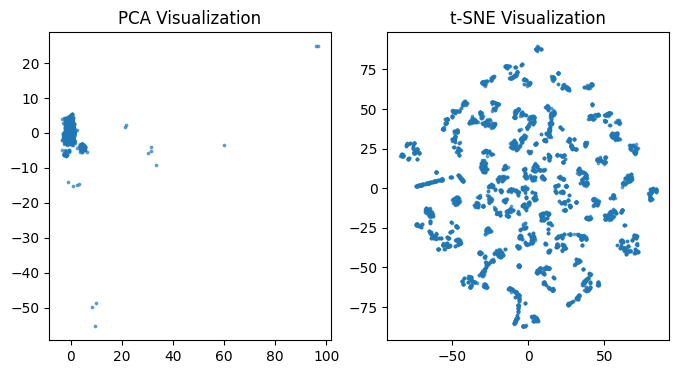

In [16]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_np)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_np)

# Plot PCA
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=3, alpha=0.6)
plt.title('PCA Visualization')

# Plot t-SNE
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=3, alpha=0.6)
plt.title('t-SNE Visualization')
plt.show()


In [17]:
#Recommend top N candidates based on cosine similarity.
#cosine similarity
# Sort by similarity

def recommend_client(query_index, embeddings, top_n=5):
    similarities = cosine_similarity([embeddings[query_index]], embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n + 1]  # Include self in top candidates
    top_indices = [idx for idx in top_indices if idx != query_index][:top_n]  # Exclude self-match

    # Display results
    print(f"\nTop {top_n} catcher_id for clients {query_index}:")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. Client {idx} - Similarity: {similarities[idx]:.4f}")

recommend_client(0, embeddings_np, top_n=10)


Top 10 catcher_id for clients 0:
1. Client 726 - Similarity: 0.9934
2. Client 355 - Similarity: 0.9896
3. Client 643 - Similarity: 0.9865
4. Client 548 - Similarity: 0.9861
5. Client 779 - Similarity: 0.9857
6. Client 822 - Similarity: 0.9856
7. Client 738 - Similarity: 0.9856
8. Client 742 - Similarity: 0.9855
9. Client 550 - Similarity: 0.9851
10. Client 789 - Similarity: 0.9851


In [ ]:
from sklearn.manifold import TSNE
# 1. Plotting the Loss Curve  # 2. Cosine Similarity Distribution  # 3. t-SNE Visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Adjust the size as needed
axs[0].plot(range(1, epochs + 1), loss_history, label='Training Loss', color='blue')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_title('Loss Curve')
axs[0].grid(True)
axs[0].legend()

similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=axs[1])
axs[1].set_title('Cosine Similarity Distribution')
axs[1].set_xlabel('Cosine Similarity')
axs[1].set_ylabel('Density')

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_np)
axs[2].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.7)
axs[2].set_title('t-SNE Visualization of Embeddings')
axs[2].set_xlabel('Dimension 1')
axs[2].set_ylabel('Dimension 2')
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
df.iloc[355]

In [ ]:
df.iloc[720]

In [ ]:
df.iloc[759]

In [ ]:
recommend_client(2, embeddings, top_n=5)

In [ ]:
df